# Week 1 Project — Kaggle EDA with Pandas, Visualisation & AutoViz

**Course:** ML, Deep Learning & Computer Vision  
**Type:** Hands-on project  
**Estimated time:** 2–3 hours  
**Dataset:** [House Prices — Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)  

---

### What you'll learn

1. **Real-world EDA workflow** — how to approach a messy Kaggle dataset from scratch
2. **AutoViz** — an automated visualisation library that generates full EDA in one line
3. **Manual deep-dive** — Pandas + Matplotlib + Seaborn for custom analysis
4. **Feature engineering** — creating features that actually improve ML models
5. **Comparing tools** — when to use AutoViz vs manual plotting

### Setup

**Option A — Kaggle Notebooks (recommended):**  
1. Go to the [competition page](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)  
2. Click "Code" → "New Notebook"  
3. The data is already at `/kaggle/input/house-prices-advanced-regression-techniques/`  

**Option B — Local:**  
1. Download `train.csv` and `test.csv` from the competition Data tab  
2. Place them in a `data/` folder next to this notebook  
3. Install dependencies: `pip install autoviz pandas matplotlib seaborn`

In [16]:
!pip install -q autoviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 56.2 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
np.random.seed(42)

print(f"Pandas: {pd.__version__}")

Pandas: 2.2.2


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd  /content/drive/MyDrive/Portofolios/Protofolio_2026/ai ml dl class/week1/house-prices-advanced-regression-techniques

/content/drive/MyDrive/Portofolios/Protofolio_2026/ai ml dl class/week1/house-prices-advanced-regression-techniques


In [8]:
!ls

data_description.txt  sample_submission.csv  test.csv  train.csv


---
## 1. Load the data

The House Prices dataset has **79 features** describing houses in Ames, Iowa.  
The goal is to predict `SalePrice` — but today we focus on **understanding** the data, not modelling.

In [9]:
# Adjust the path for your environment
# Kaggle:  '/kaggle/input/house-prices-advanced-regression-techniques/train.csv'
# Local:   'data/train.csv' or 'train.csv' if directly in the notebook's folder
# Google Drive: '/content/drive/MyDrive/data/train.csv' or specific project folder

import os
kaggle_path = '/kaggle/input/house-prices-advanced-regression-techniques/train.csv'
drive_path = '/content/drive/MyDrive/data/train.csv'

# Check for train.csv directly in the current working directory (after %cd)
current_dir_path = 'train.csv'
# Check for train.csv in a 'data' subfolder relative to the current working directory
local_data_path = 'data/train.csv'

if os.path.exists(kaggle_path):
    DATA_PATH = kaggle_path
elif os.path.exists(drive_path):
    DATA_PATH = drive_path
elif os.path.exists(current_dir_path):
    DATA_PATH = current_dir_path
elif os.path.exists(local_data_path):
    DATA_PATH = local_data_path
else:
    raise FileNotFoundError(
        "Dataset not found. Download train.csv from:\n"
        "https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data\n"
        "and place it in a 'data/' folder next to this notebook, or directly in its folder in Google Drive (e.g., /content/drive/MyDrive/Portofolios/Protofolio_2026/ai ml dl class/week1/house-prices-advanced-regression-techniques/train.csv) or in /content/drive/MyDrive/data/train.csv."
    )

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape} — {df.shape[0]} houses, {df.shape[1]} columns")
df.head()

Shape: (1460, 81) — 1460 houses, 81 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 2. First look — understand the dataset in 5 minutes

Before any plots, understand what you're working with.

In [10]:
# Column types
print("=== DATA TYPES ===")
print(f"Numeric columns:     {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include=['object']).shape[1]}")
print(f"Total:               {df.shape[1]}")

=== DATA TYPES ===
Numeric columns:     38
Categorical columns: 43
Total:               81


In [11]:
# Quick statistics for numeric columns
df.describe().round(1)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.0,1460.0,1201.0,1460.0,1460.0,1460.0,1460.0,1460.0,1452.0,1460.0,...,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0
mean,730.5,56.9,70.0,10516.8,6.1,5.6,1971.3,1984.9,103.7,443.6,...,94.2,46.7,22.0,3.4,15.1,2.8,43.5,6.3,2007.8,180921.2
std,421.6,42.3,24.3,9981.3,1.4,1.1,30.2,20.6,181.1,456.1,...,125.3,66.3,61.1,29.3,55.8,40.2,496.1,2.7,1.3,79442.5
min,1.0,20.0,21.0,1300.0,1.0,1.0,1872.0,1950.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2006.0,34900.0
25%,365.8,20.0,59.0,7553.5,5.0,5.0,1954.0,1967.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2007.0,129975.0
50%,730.5,50.0,69.0,9478.5,6.0,5.0,1973.0,1994.0,0.0,383.5,...,0.0,25.0,0.0,0.0,0.0,0.0,0.0,6.0,2008.0,163000.0
75%,1095.2,70.0,80.0,11601.5,7.0,6.0,2000.0,2004.0,166.0,712.2,...,168.0,68.0,0.0,0.0,0.0,0.0,0.0,8.0,2009.0,214000.0
max,1460.0,190.0,313.0,215245.0,10.0,9.0,2010.0,2010.0,1600.0,5644.0,...,857.0,547.0,552.0,508.0,480.0,738.0,15500.0,12.0,2010.0,755000.0


In [12]:
# Missing values — sorted by severity
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("pct", ascending=False)

print(f"Columns with missing data: {len(missing_df)} out of {df.shape[1]}")
print(f"\nTop 15 by percentage missing:")
print(missing_df.head(15))

Columns with missing data: 19 out of 81

Top 15 by percentage missing:
              count   pct
PoolQC         1453  99.5
MiscFeature    1406  96.3
Alley          1369  93.8
Fence          1179  80.8
MasVnrType      872  59.7
FireplaceQu     690  47.3
LotFrontage     259  17.7
GarageType       81   5.5
GarageYrBlt      81   5.5
GarageFinish     81   5.5
GarageQual       81   5.5
GarageCond       81   5.5
BsmtExposure     38   2.6
BsmtFinType2     38   2.6
BsmtQual         37   2.5


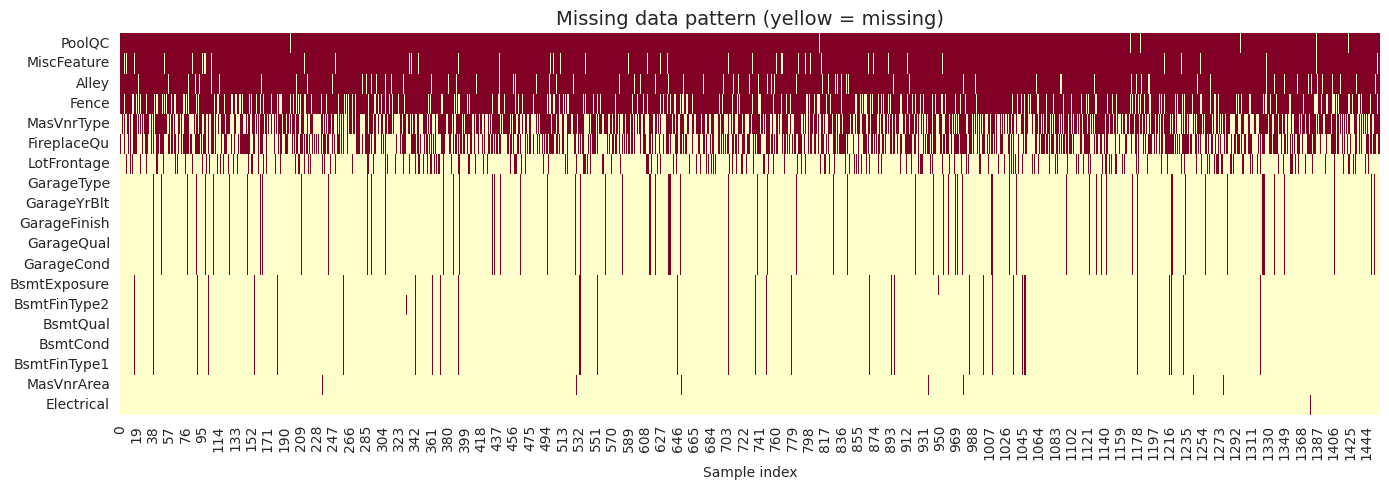

In [13]:
# Visualise missing data as a heatmap
cols_with_missing = missing_df.head(20).index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df[cols_with_missing].isnull().T, cbar=False, cmap="YlOrRd",
            yticklabels=True, ax=ax)
ax.set_title("Missing data pattern (yellow = missing)", fontsize=14)
ax.set_xlabel("Sample index")
plt.tight_layout()
plt.show()

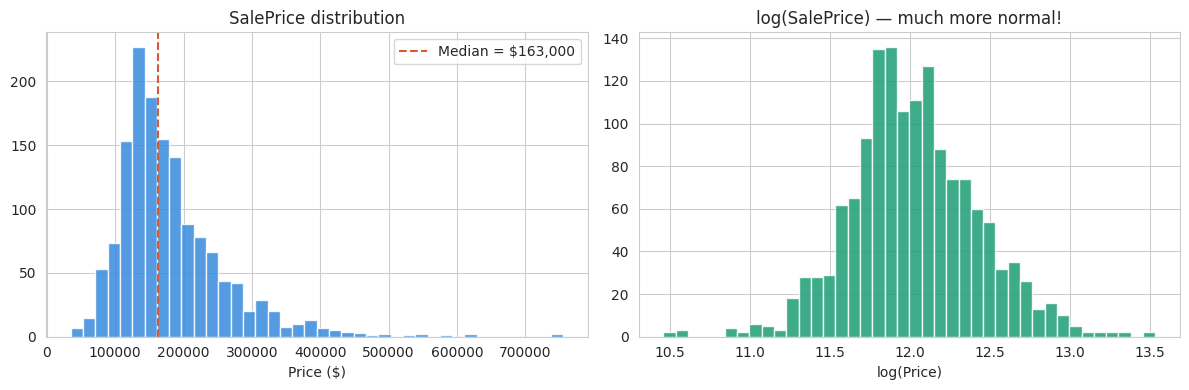

Skewness (raw): 1.88
Skewness (log): 0.12
→ Log transform makes it nearly normal — important for regression!


In [14]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw
axes[0].hist(df["SalePrice"], bins=40, color="#378ADD", edgecolor="white", alpha=0.85)
axes[0].axvline(df["SalePrice"].median(), color="#D85A30", linestyle="--",
                label=f"Median = ${df['SalePrice'].median():,.0f}")
axes[0].set_title("SalePrice distribution")
axes[0].set_xlabel("Price ($)")
axes[0].legend()

# Log-transformed
axes[1].hist(np.log1p(df["SalePrice"]), bins=40, color="#1D9E75", edgecolor="white", alpha=0.85)
axes[1].set_title("log(SalePrice) — much more normal!")
axes[1].set_xlabel("log(Price)")

plt.tight_layout()
plt.show()

print(f"Skewness (raw): {df['SalePrice'].skew():.2f}")
print(f"Skewness (log): {np.log1p(df['SalePrice']).skew():.2f}")
print("→ Log transform makes it nearly normal — important for regression!")

---
## 3. AutoViz — automated EDA in one line

### What is AutoViz?

[AutoViz](https://github.com/AutoViML/AutoViz) automatically generates a comprehensive set of visualisations for any dataset. It:

- Detects column types (numeric, categorical, boolean)
- Creates distributions, scatter plots, box plots, heatmaps
- Identifies important features relative to the target
- Handles large datasets by sampling intelligently
- Works with a single function call

### When to use AutoViz vs manual plotting

| Situation | Use |
|-----------|-----|
| First look at a new dataset | **AutoViz** — get oriented fast |
| Quick sanity check | **AutoViz** — are there obvious issues? |
| Presentation-quality charts | **Manual** — full control over aesthetics |
| Custom analysis / hypothesis testing | **Manual** — specific questions need specific plots |
| Feature engineering insights | **Both** — AutoViz to explore, manual to deep-dive |

The best workflow: **AutoViz first** to get a big-picture overview, then **manual plots** to investigate specific findings.

In [17]:
# Install if needed (uncomment the line below)
# !pip install autoviz

from autoviz import AutoViz_Class

AV = AutoViz_Class()
print("AutoViz loaded!")

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)
AutoViz loaded!


### 3.1 Basic AutoViz — one line, full EDA

The main function signature:
```python
AV.AutoViz(
    filename='',           # path to CSV (or '' if passing a DataFrame)
    sep=',',               # delimiter
    depVar='SalePrice',    # target variable (optional)
    dfte=df,               # DataFrame (if filename is '')
    header=0,              # header row
    verbose=1,             # 0=silent, 1=charts, 2=charts+details
    lowess=False,          # add LOWESS trendlines to scatters
    chart_format='svg',    # 'svg', 'png', 'jpg', 'html'
    max_rows_analyzed=1500,# sample size for large datasets
    max_cols_analyzed=30,  # max features to plot
)
```

In [18]:
# Run AutoViz on the full dataset with SalePrice as target
# This generates ~15-25 plots automatically

dft = AV.AutoViz(
    filename='',
    sep=',',
    depVar='SalePrice',
    dfte=df,
    header=0,
    verbose=1,
    lowess=False,
    chart_format='svg',
    max_rows_analyzed=1500,
    max_cols_analyzed=30,
)

Shape of your Data Set loaded: (1460, 81)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  3
    Number of Integer-Categorical Columns =  31
    Number of String-Categorical Columns =  37
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  3
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  2
    Number of ID Columns =  1
    Number of Columns to Delete =  3
    80 Predictors classified...
        4 variable(s) removed since they were ID or low-information variables
        List of variables removed: ['Id', 'Alley', 'PoolQC', 'MiscFeature']

################ Regress

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
LotFrontage,float64,17.739726,NA,21.000000,313.000000,"259 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 88 outliers greater than upper bound (111.50) or lower than lower bound(27.50). Cap them or remove them."
MasVnrArea,float64,0.547945,NA,0.000000,1600.000000,"8 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 96 outliers greater than upper bound (415.00) or lower than lower bound(-249.00). Cap them or remove them."
GarageYrBlt,float64,5.547945,NA,1900.000000,2010.000000,"81 missing values. Impute them with mean, median, mode, or a constant value such as 123."
MSSubClass,int64,0.000000,1,20.000000,190.000000,Column has 103 outliers greater than upper bound (145.00) or lower than lower bound(-55.00). Cap them or remove them.
MSZoning,object,0.000000,0,,,1 rare categories: ['C (all)']. Group them into a single category or drop the categories.
LotArea,int64,0.000000,73,1300.000000,215245.000000,Column has 69 outliers greater than upper bound (17673.50) or lower than lower bound(1481.50). Cap them or remove them.
Street,object,0.000000,0,,,No issue
LotShape,object,0.000000,0,,,1 rare categories: ['IR3']. Group them into a single category or drop the categories.
LandContour,object,0.000000,0,,,No issue
Utilities,object,0.000000,0,,,No issue


Number of All Scatter Plots = 6
Could not draw some Time Series plots. agg function failed [how->mean,dtype->object]
All Plots done
Time to run AutoViz = 9 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [19]:
# Run AutoViz on the full dataset with SalePrice as target
# This generates ~15-25 plots automatically

dft = AV.AutoViz(
    filename='',
    sep=',',
    depVar='SalePrice',
    dfte=df,
    header=0,
    verbose=1,
    lowess=False,
    chart_format='svg',
    max_rows_analyzed=1500,
    max_cols_analyzed=90,
)

Shape of your Data Set loaded: (1460, 81)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  3
    Number of Integer-Categorical Columns =  31
    Number of String-Categorical Columns =  37
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  3
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  2
    Number of ID Columns =  1
    Number of Columns to Delete =  3
    80 Predictors classified...
        4 variable(s) removed since they were ID or low-information variables
        List of variables removed: ['Id', 'Alley', 'PoolQC', 'MiscFeature']

################ Regress

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
MSSubClass,int64,0.000000,1,20.000000,190.000000,Column has 103 outliers greater than upper bound (145.00) or lower than lower bound(-55.00). Cap them or remove them.
MSZoning,object,0.000000,0,,,1 rare categories: ['C (all)']. Group them into a single category or drop the categories.
LotFrontage,float64,17.739726,NA,21.000000,313.000000,"259 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 88 outliers greater than upper bound (111.50) or lower than lower bound(27.50). Cap them or remove them."
LotArea,int64,0.000000,73,1300.000000,215245.000000,Column has 69 outliers greater than upper bound (17673.50) or lower than lower bound(1481.50). Cap them or remove them.
Street,object,0.000000,0,,,No issue
LotShape,object,0.000000,0,,,1 rare categories: ['IR3']. Group them into a single category or drop the categories.
LandContour,object,0.000000,0,,,No issue
Utilities,object,0.000000,0,,,No issue
LotConfig,object,0.000000,0,,,1 rare categories: ['FR3']. Group them into a single category or drop the categories.
LandSlope,object,0.000000,0,,,1 rare categories: ['Sev']. Group them into a single category or drop the categories.


Number of All Scatter Plots = 6
Could not draw some Time Series plots. agg function failed [how->mean,dtype->object]
All Plots done
Time to run AutoViz = 32 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


### 3.2 Interpreting AutoViz output

AutoViz generates several categories of plots. Here's what to look for in each:

| Plot type | What it shows | What to look for |
|-----------|--------------|------------------|
| **Distribution plots** | Histogram of each numeric column | Skewness, outliers, multi-modal distributions |
| **Scatter plots** | Pairs of numeric columns vs target | Linear/nonlinear relationships, clusters |
| **Box plots** | Numeric vs categorical | Which categories have higher/lower values |
| **Heatmap** | Correlation matrix | Strongly correlated features (multicollinearity) |
| **Violin plots** | Distribution by category | Shape differences between groups |
| **Bar plots** | Categorical frequencies | Imbalanced categories, rare values |

### 3.3 Targeted AutoViz — explore specific subsets

You can run AutoViz on filtered subsets for deeper investigation.

In [20]:
# AutoViz on just the top features related to price
key_cols = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars",
            "TotalBsmtSF", "FullBath", "YearBuilt", "YearRemodAdd"]
df_subset = df[key_cols].copy()

dft_sub = AV.AutoViz(
    filename='',
    sep=',',
    depVar='SalePrice',
    dfte=df_subset,
    header=0,
    verbose=1,
    chart_format='svg',
    max_rows_analyzed=1500,
)

Shape of your Data Set loaded: (1460, 8)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  6
    Number of String-Categorical Columns =  0
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  1
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    7 Predictors classified...
        No variables removed since no ID or low-information variables found in data set

################ Regression problem #####################
To fix these data quality issues in 

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
OverallQual,int64,0.000000,0,1,10,Column has 2 outliers greater than upper bound (10.00) or lower than lower bound(2.00). Cap them or remove them.
GrLivArea,int64,0.000000,58,334,5642,Column has 31 outliers greater than upper bound (2747.62) or lower than lower bound(158.62). Cap them or remove them.
GarageCars,int64,0.000000,0,0,4,Column has 5 outliers greater than upper bound (3.50) or lower than lower bound(-0.50). Cap them or remove them.
TotalBsmtSF,int64,0.000000,49,0,6110,Column has 61 outliers greater than upper bound (2052.00) or lower than lower bound(42.00). Cap them or remove them.
FullBath,int64,0.000000,0,0,3,No issue
YearBuilt,int64,0.000000,7,1872,2010,Column has 7 outliers greater than upper bound (2069.00) or lower than lower bound(1885.00). Cap them or remove them.
YearRemodAdd,int64,0.000000,4,1950,2010,Possible date-time colum: transform before modeling step.
SalePrice,int64,0.000000,45,34900,755000,Target column


Number of All Scatter Plots = 21
All Plots done
Time to run AutoViz = 4 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [21]:
# AutoViz on categorical features only
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_cat = df[cat_cols + ["SalePrice"]].copy()

dft_cat = AV.AutoViz(
    filename='',
    sep=',',
    depVar='SalePrice',
    dfte=df_cat,
    header=0,
    verbose=1,
    chart_format='svg',
    max_cols_analyzed=15,
)

Shape of your Data Set loaded: (1460, 44)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  0
    Number of String-Categorical Columns =  37
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  3
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  3
    43 Predictors classified...
        3 variable(s) removed since they were ID or low-information variables
        List of variables removed: ['Alley', 'PoolQC', 'MiscFeature']

################ Regression pro

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
MSZoning,object,0.000000,0,,,1 rare categories: ['C (all)']. Group them into a single category or drop the categories.
Street,object,0.000000,0,,,No issue
LotShape,object,0.000000,0,,,1 rare categories: ['IR3']. Group them into a single category or drop the categories.
LandContour,object,0.000000,0,,,No issue
Utilities,object,0.000000,0,,,No issue
LotConfig,object,0.000000,0,,,1 rare categories: ['FR3']. Group them into a single category or drop the categories.
LandSlope,object,0.000000,0,,,1 rare categories: ['Sev']. Group them into a single category or drop the categories.
Neighborhood,object,0.000000,1,,,"3 rare categories: ['Veenker', 'NPkVill', 'Blueste']. Group them into a single category or drop the categories."
Condition1,object,0.000000,0,,,"4 rare categories: ['RRAe', 'PosA', 'RRNn', 'RRNe']. Group them into a single category or drop the categories."
Condition2,object,0.000000,0,,,"7 rare categories: ['Feedr', 'Artery', 'RRNn', 'PosN', 'PosA', 'RRAn', 'RRAe']. Group them into a single category or drop the categories."


All Plots done
Time to run AutoViz = 10 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


### 3.4 Saving AutoViz output

AutoViz can save all plots to a folder for reports.

In [22]:
# Save all AutoViz charts to a folder
import os
os.makedirs("autoviz_output", exist_ok=True)

dft_saved = AV.AutoViz(
    filename='',
    sep=',',
    depVar='SalePrice',
    dfte=df,
    header=0,
    verbose=1,
    chart_format='png',
    save_plot_dir='autoviz_output',
)

# Check what was saved
for f in sorted(os.listdir('autoviz_output')):
    print(f"  {f}")

Shape of your Data Set loaded: (1460, 81)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  3
    Number of Integer-Categorical Columns =  31
    Number of String-Categorical Columns =  37
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  3
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  2
    Number of ID Columns =  1
    Number of Columns to Delete =  3
    80 Predictors classified...
        4 variable(s) removed since they were ID or low-information variables
        List of variables removed: ['Id', 'Alley', 'PoolQC', 'MiscFeature']

################ Regress

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
LotFrontage,float64,17.739726,NA,21.000000,313.000000,"259 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 88 outliers greater than upper bound (111.50) or lower than lower bound(27.50). Cap them or remove them."
MasVnrArea,float64,0.547945,NA,0.000000,1600.000000,"8 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 96 outliers greater than upper bound (415.00) or lower than lower bound(-249.00). Cap them or remove them."
GarageYrBlt,float64,5.547945,NA,1900.000000,2010.000000,"81 missing values. Impute them with mean, median, mode, or a constant value such as 123."
MSSubClass,int64,0.000000,1,20.000000,190.000000,Column has 103 outliers greater than upper bound (145.00) or lower than lower bound(-55.00). Cap them or remove them.
MSZoning,object,0.000000,0,,,1 rare categories: ['C (all)']. Group them into a single category or drop the categories.
LotArea,int64,0.000000,73,1300.000000,215245.000000,Column has 69 outliers greater than upper bound (17673.50) or lower than lower bound(1481.50). Cap them or remove them.
Street,object,0.000000,0,,,No issue
LotShape,object,0.000000,0,,,1 rare categories: ['IR3']. Group them into a single category or drop the categories.
LandContour,object,0.000000,0,,,No issue
Utilities,object,0.000000,0,,,No issue


Number of All Scatter Plots = 6
Could not draw some Time Series plots. agg function failed [how->mean,dtype->object]
All Plots done
Time to run AutoViz = 8 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


---
## 4. Manual deep-dive — going beyond AutoViz

AutoViz gave us the big picture. Now we dig into specific findings with custom plots.

### 4.1 Top correlations with SalePrice

In [23]:
# Correlation with target — sorted
numeric_df = df.select_dtypes(include=[np.number])
corr_with_price = numeric_df.corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#1D9E75" if v > 0 else "#E24B4A" for v in corr_with_price]
ax.barh(corr_with_price.index, corr_with_price.values, color=colors, height=0.7)
ax.axvline(0, color="gray", linewidth=0.5)
ax.axvline(0.5, color="#1D9E75", linewidth=0.8, linestyle="--", alpha=0.5, label="Strong positive")
ax.axvline(-0.5, color="#E24B4A", linewidth=0.8, linestyle="--", alpha=0.5, label="Strong negative")
ax.set_xlabel("Correlation with SalePrice")
ax.set_title("Feature correlations with SalePrice")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 positive correlations:")
print(corr_with_price.head(10).round(3).to_string())


Top 10 positive correlations:
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507


### 4.2 Scatter plots of top features

In [24]:
top_features = corr_with_price.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    ax.scatter(df[feat], df["SalePrice"], alpha=0.4, s=12, color="#378ADD", edgecolors="white", linewidth=0.3)

    # Add trendline
    valid = df[[feat, "SalePrice"]].dropna()
    z = np.polyfit(valid[feat], valid["SalePrice"], 1)
    x_line = np.linspace(valid[feat].min(), valid[feat].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color="#D85A30", linewidth=2, linestyle="--")

    r = corr_with_price[feat]
    ax.set_title(f"{feat} (r = {r:.2f})")
    ax.set_xlabel(feat)
    ax.set_ylabel("SalePrice")

plt.suptitle("Top 6 features vs SalePrice", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Categorical features — which ones matter most?

In [25]:
# For each categorical feature, compute the range of median SalePrice across categories
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_impact = {}

for col in cat_cols:
    medians = df.groupby(col)["SalePrice"].median()
    if len(medians) > 1:
        cat_impact[col] = medians.max() - medians.min()

cat_impact = pd.Series(cat_impact).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(cat_impact.index, cat_impact.values, color="#7F77DD", height=0.7)
ax.set_xlabel("Price range across categories (median)")
ax.set_title("Categorical feature impact on SalePrice")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print("\nTop 5 most impactful categorical features:")
for feat in cat_impact.head(5).index:
    medians = df.groupby(feat)["SalePrice"].median().sort_values(ascending=False)
    print(f"\n  {feat}:")
    print(f"    {medians.head(3).to_string()}")


Top 5 most impactful categorical features:

  PoolQC:
    PoolQC
Ex    490000.0
Fa    215500.0
Gd    171000.0

  ExterQual:
    ExterQual
Ex    364606.5
Gd    220000.0
TA    139450.0

  Condition2:
    Condition2
PosA    325000.0
PosN    284875.0
RRAe    190000.0

  Neighborhood:
    Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0

  Exterior2nd:
    Exterior2nd
Other      319000.0
CmentBd    238750.0
VinylSd    200070.5


### 4.4 Deep-dive: Neighbourhood analysis

In [26]:
# Neighbourhood is often the #1 predictor in real estate
nbhd_stats = df.groupby("Neighborhood").agg(
    median_price=("SalePrice", "median"),
    count=("SalePrice", "count"),
    avg_quality=("OverallQual", "mean"),
    avg_area=("GrLivArea", "mean"),
).sort_values("median_price", ascending=False).round(0)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(nbhd_stats)))
bars = ax.barh(nbhd_stats.index, nbhd_stats["median_price"], color=colors, height=0.7)
ax.set_xlabel("Median Sale Price ($)")
ax.set_title("Median house price by neighbourhood")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Annotate count
for bar, count in zip(bars, nbhd_stats["count"]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'n={int(count)}', va='center', fontsize=8, color="gray")

plt.tight_layout()
plt.show()

### 4.5 Multi-feature interaction

In [27]:
# Quality × Area interaction — the two biggest predictors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter coloured by OverallQual
sc = axes[0].scatter(df["GrLivArea"], df["SalePrice"],
                     c=df["OverallQual"], cmap="RdYlGn", alpha=0.6, s=20, edgecolors="white", linewidth=0.3)
plt.colorbar(sc, ax=axes[0], label="Overall Quality")
axes[0].set_xlabel("Living Area (sq ft)")
axes[0].set_ylabel("Sale Price ($)")
axes[0].set_title("Price vs Area, coloured by Quality")

# Box plot of price by quality rating
sns.boxplot(data=df, x="OverallQual", y="SalePrice", palette="RdYlGn", ax=axes[1])
axes[1].set_title("Price distribution by quality rating")
axes[1].set_xlabel("Overall Quality (1-10)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Outlier detection
outliers = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
print(f"\nPotential outliers: {len(outliers)} houses with >4000 sq ft but <$300k")
if len(outliers) > 0:
    print(outliers[["GrLivArea", "SalePrice", "OverallQual", "Neighborhood"]].to_string())


Potential outliers: 2 houses with >4000 sq ft but <$300k
      GrLivArea  SalePrice  OverallQual Neighborhood
523     4676      184750        10         Edwards  
1298    5642      160000        10         Edwards  


---
## 5. Feature engineering

Based on our EDA findings, let's create features that could improve a model.

In [28]:
# Create a working copy
df_eng = df.copy()

# 1. Total square footage (combining basement + above-ground)
df_eng["TotalSF"] = df_eng["TotalBsmtSF"].fillna(0) + df_eng["1stFlrSF"] + df_eng["2ndFlrSF"]

# 2. Total bathrooms
df_eng["TotalBath"] = (df_eng["FullBath"] + 0.5 * df_eng["HalfBath"] +
                        df_eng["BsmtFullBath"].fillna(0) + 0.5 * df_eng["BsmtHalfBath"].fillna(0))

# 3. House age and remodel age
df_eng["HouseAge"] = df_eng["YrSold"] - df_eng["YearBuilt"]
df_eng["RemodAge"] = df_eng["YrSold"] - df_eng["YearRemodAdd"]

# 4. Has feature flags
df_eng["HasGarage"] = (df_eng["GarageArea"].fillna(0) > 0).astype(int)
df_eng["HasPool"] = (df_eng["PoolArea"] > 0).astype(int)
df_eng["HasFireplace"] = (df_eng["Fireplaces"] > 0).astype(int)
df_eng["Has2ndFloor"] = (df_eng["2ndFlrSF"] > 0).astype(int)

# 5. Price per square foot (for analysis only — can't use in prediction)
df_eng["PricePerSF"] = df_eng["SalePrice"] / df_eng["TotalSF"]

print("New features created:")
new_cols = ["TotalSF", "TotalBath", "HouseAge", "RemodAge",
            "HasGarage", "HasPool", "HasFireplace", "Has2ndFloor", "PricePerSF"]
print(df_eng[new_cols].describe().round(1))

New features created:
       TotalSF  TotalBath  HouseAge  RemodAge  HasGarage  HasPool  \
count   1460.0   1460.0     1460.0    1460.0    1460.0    1460.0    
mean    2567.0      2.2       36.5      23.0       0.9       0.0    
std      821.7      0.8       30.3      20.6       0.2       0.1    
min      334.0      1.0        0.0      -1.0       0.0       0.0    
25%     2009.5      2.0        8.0       4.0       1.0       0.0    
50%     2474.0      2.0       35.0      14.0       1.0       0.0    
75%     3004.0      2.5       54.0      41.0       1.0       0.0    
max    11752.0      6.0      136.0      60.0       1.0       1.0    

       HasFireplace  Has2ndFloor  PricePerSF  
count     1460.0       1460.0       1460.0    
mean         0.5          0.4         69.9    
std          0.5          0.5         15.4    
min          0.0          0.0         13.6    
25%          0.0          0.0         60.5    
50%          1.0          0.0         69.7    
75%          1.0          1

In [29]:
# Are our engineered features better predictors?
eng_corr = df_eng[["SalePrice"] + new_cols[:-1]].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
orig_top = corr_with_price.head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original top features
axes[0].barh(orig_top.index, orig_top.values, color="#378ADD", height=0.6)
axes[0].set_title("Original top features")
axes[0].set_xlabel("Correlation with SalePrice")
axes[0].set_xlim(0, 1)

# Engineered features
colors = ["#1D9E75" if v > 0.5 else "#7F77DD" for v in eng_corr.values]
axes[1].barh(eng_corr.index, eng_corr.values, color=colors, height=0.6)
axes[1].set_title("Engineered features")
axes[1].set_xlabel("Correlation with SalePrice")
axes[1].set_xlim(-0.5, 1)

plt.suptitle("Original vs engineered feature correlations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTotalSF correlation:", eng_corr["TotalSF"].round(3),
      "— better than any single original area feature!")


TotalSF correlation: 0.782 — better than any single original area feature!


### 5.2 AutoViz on engineered features

In [30]:
# Run AutoViz on our engineered features to verify they look clean
eng_cols = ["SalePrice", "TotalSF", "TotalBath", "HouseAge", "RemodAge",
            "HasGarage", "HasFireplace", "OverallQual"]
df_eng_subset = df_eng[eng_cols].copy()

dft_eng = AV.AutoViz(
    filename='',
    sep=',',
    depVar='SalePrice',
    dfte=df_eng_subset,
    header=0,
    verbose=1,
    chart_format='svg',
)

Shape of your Data Set loaded: (1460, 8)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  1
    Number of Integer-Categorical Columns =  4
    Number of String-Categorical Columns =  0
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  2
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    7 Predictors classified...
        No variables removed since no ID or low-information variables found in data set

################ Regression problem #####################
To fix these data quality issues in 

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
TotalSF,int64,0.000000,65,334.000000,11752.000000,Column has 25 outliers greater than upper bound (4495.75) or lower than lower bound(517.75). Cap them or remove them.
TotalBath,float64,0.000000,NA,1.000000,6.000000,Column has 394 outliers greater than upper bound (3.25) or lower than lower bound(1.25). Cap them or remove them.
HouseAge,int64,0.000000,8,0.000000,136.000000,Column has 8 outliers greater than upper bound (123.00) or lower than lower bound(-61.00). Cap them or remove them.
RemodAge,int64,0.000000,4,-1.000000,60.000000,No issue
HasGarage,int64,0.000000,0,0.000000,1.000000,No issue
HasFireplace,int64,0.000000,0,0.000000,1.000000,No issue
OverallQual,int64,0.000000,0,1.000000,10.000000,Column has 2 outliers greater than upper bound (10.00) or lower than lower bound(2.00). Cap them or remove them.
SalePrice,int64,0.000000,45,34900.000000,755000.000000,Target column


All Plots done
Time to run AutoViz = 2 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


---
## 6. Handling missing data

Now let's clean the dataset properly.

In [31]:
# Strategy per column based on domain knowledge
df_clean = df_eng.copy()

# Columns where NaN means "none" (no garage, no pool, etc.)
none_cols = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
             "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish",
             "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature"]
for col in none_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("None")

# Numeric: fill with 0 (no basement, no garage → 0 area)
zero_cols = ["BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea",
             "MasVnrArea"]
for col in zero_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# LotFrontage: fill with neighbourhood median (houses on same street are similar)
df_clean["LotFrontage"] = df_clean.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# GarageYrBlt: fill with YearBuilt (garage likely built with house)
df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].fillna(df_clean["YearBuilt"])

# Remaining categoricals: fill with mode
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Remaining numerics: fill with median
for col in df_clean.select_dtypes(include=[np.number]).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"Dataset shape: {df_clean.shape}")

Missing values remaining: 0
Dataset shape: (1460, 90)


---
## 7. Final EDA report dashboard

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("House Prices — EDA Report", fontsize=18, fontweight="bold", y=1.01)

# 1. Price distribution
axes[0,0].hist(df_clean["SalePrice"], bins=40, color="#378ADD", edgecolor="white")
axes[0,0].axvline(df_clean["SalePrice"].median(), color="#D85A30", linestyle="--")
axes[0,0].set_title("Sale price distribution")
axes[0,0].set_xlabel("Price ($)")

# 2. Top correlations
top8 = corr_with_price.head(8)
axes[0,1].barh(top8.index, top8.values, color="#1D9E75", height=0.6)
axes[0,1].set_title("Top 8 correlated features")
axes[0,1].set_xlabel("Correlation")

# 3. Quality vs price
sns.boxplot(data=df_clean, x="OverallQual", y="SalePrice", palette="RdYlGn", ax=axes[0,2])
axes[0,2].set_title("Price by quality")

# 4. Area vs price
axes[1,0].scatter(df_clean["TotalSF"], df_clean["SalePrice"], alpha=0.4, s=10, color="#7F77DD")
axes[1,0].set_title("Total SF vs price")
axes[1,0].set_xlabel("Total sq ft")
axes[1,0].set_ylabel("Price ($)")

# 5. Age vs price
axes[1,1].scatter(df_clean["HouseAge"], df_clean["SalePrice"], alpha=0.4, s=10, color="#D85A30")
axes[1,1].set_title("House age vs price")
axes[1,1].set_xlabel("Age (years)")

# 6. Neighbourhood (top 10)
nbhd_top = df_clean.groupby("Neighborhood")["SalePrice"].median().nlargest(10)
axes[1,2].barh(nbhd_top.index, nbhd_top.values, color="#378ADD", height=0.6)
axes[1,2].set_title("Top 10 neighbourhoods")
axes[1,2].set_xlabel("Median price ($)")

# 7. Correlation heatmap (top features)
top_feats = ["SalePrice", "OverallQual", "TotalSF", "GarageCars",
             "TotalBath", "YearBuilt", "HouseAge"]
sns.heatmap(df_clean[top_feats].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[2,0], square=True, cbar_kws={"shrink":0.8})
axes[2,0].set_title("Feature correlations")

# 8. Sale condition
sns.boxplot(data=df_clean, x="SaleCondition", y="SalePrice", palette="Set2", ax=axes[2,1])
axes[2,1].set_title("Price by sale condition")
axes[2,1].tick_params(axis='x', rotation=30)

# 9. Year built trend
year_price = df_clean.groupby("YearBuilt")["SalePrice"].median()
axes[2,2].plot(year_price.index, year_price.values, color="#1D9E75", linewidth=1.5)
axes[2,2].fill_between(year_price.index, year_price.values, alpha=0.15, color="#1D9E75")
axes[2,2].set_title("Median price by year built")
axes[2,2].set_xlabel("Year")
axes[2,2].set_ylabel("Median price ($)")

plt.tight_layout()
plt.show()

---
## 8. Your turn — exercises

### Exercise 1: AutoViz comparison

Run AutoViz on two subsets:
- Houses built **before 1960**
- Houses built **after 2000**

Compare the outputs. Write 3 observations about how old vs new houses differ in terms of features, prices, and quality.

In [ ]:
# Your code here
# df_old = df[df["YearBuilt"] < 1960]
# df_new = df[df["YearBuilt"] > 2000]


**Your 3 observations:**
1. ...
2. ...
3. ...

### Exercise 2: Neighbourhood deep-dive

Pick the **3 most expensive** and **3 cheapest** neighbourhoods. Create a 2×3 subplot where each panel is a scatter of `GrLivArea` vs `SalePrice` for one neighbourhood. Add trendlines. What differences do you see in the price-per-square-foot relationship?

In [ ]:
# Your code here


### Exercise 3: Create 3 new features

Engineer at least 3 new features based on the EDA insights. For each one:
- Explain your reasoning
- Compute its correlation with SalePrice
- Plot it vs SalePrice

Ideas: quality-area interaction, outdoor space ratio, garage quality score, renovation ROI.

In [ ]:
# Your code here


### Exercise 4: Complete EDA report

Write a **10-line summary** (in a markdown cell below) of your key EDA findings. Structure it as:
- 3 most important numeric predictors and why
- 2 most important categorical predictors and why
- 2 feature engineering ideas that worked
- 2 data quality issues you found
- 1 surprise or unexpected finding

**Your EDA summary:**

...


---
## 9. AutoViz tips & tricks

### Quick reference

```python
from autoviz import AutoViz_Class
AV = AutoViz_Class()

# Basic — from CSV file
dft = AV.AutoViz('data.csv', depVar='target')

# From DataFrame
dft = AV.AutoViz('', dfte=df, depVar='target')

# With LOWESS trendlines (slower but more informative)
dft = AV.AutoViz('', dfte=df, depVar='target', lowess=True)

# Save all charts
dft = AV.AutoViz('', dfte=df, depVar='target',
                  chart_format='png', save_plot_dir='charts/')

# Large dataset — limit rows and columns
dft = AV.AutoViz('', dfte=df, depVar='target',
                  max_rows_analyzed=2000, max_cols_analyzed=20)

# No target (unsupervised exploration)
dft = AV.AutoViz('', dfte=df, depVar='')
```

### Common issues

| Problem | Solution |
|---------|----------|
| Too many plots | Reduce `max_cols_analyzed` |
| Slow on large data | Reduce `max_rows_analyzed` |
| Plots too cluttered | Pass a subset of columns |
| Want to save charts | Set `chart_format='png'` and `save_plot_dir='path/'` |
| No target variable | Set `depVar=''` |

---
## Summary

In this project, you learned:

1. **AutoViz** — one-line automated EDA that gives you the big picture in seconds
2. **Manual EDA** — custom Pandas + Matplotlib + Seaborn for targeted investigation
3. **The full workflow**: load → inspect → AutoViz overview → manual deep-dive → feature engineer → clean → report
4. **Feature engineering** — combining columns, creating flags, domain-driven features
5. **Missing data strategy** — domain knowledge matters (NaN = "none" vs NaN = unknown)

### Key takeaway

**AutoViz and manual plotting are complementary, not competing.**  
Use AutoViz to get oriented (2 minutes), then spend your time on the plots that answer your specific questions.